# Descobrindo Segmentos de Uso de Assinantes com Agrupamento K-Means (PROC FASTCLUS)


## Resumo Executivo

Uma equipe de análise de telecomunicações começa com uma única coluna não rotulada de consumo mensal de dados móveis e quer saber se ela esconde níveis distintos de clientes. Usando **PROC FASTCLUS** (análise de cluster disjunto k-means), a equipe agrupa os assinantes pelo uso em escala logarítmica, compara soluções de dois, três e quatro segmentos nos critérios que o FASTCLUS realmente reporta, e opta pela divisão de três segmentos. Nesta execução, os três segmentos descobertos têm uso médio de **3.1 GB**, **12.8 GB** e **45.4 GB** por mês e contêm **49**, **34** e **17** assinantes — uma estrutura clara de leve / médio / pesado. Ao cruzar os rótulos descobertos com um rótulo gerador retido, **96 de 100** assinantes são recuperados corretamente. Cada assinante sai do modelo com um rótulo de segmento definitivo e uma pontuação de distância ao centroide, pronto para o desenho de planos e a segmentação de retenção.

> **Por que FASTCLUS e não um modelo de mistura finita?** A segmentação de uso é a tarefa clássica de um modelo de mistura finita (PROC HPFMM / PROC FMM). Esses procedimentos ainda não estão numericamente implementados nesta build, então este notebook alcança o mesmo objetivo — a descoberta não supervisionada de níveis de uso latentes — com o procedimento k-means totalmente numérico e implementado **PROC FASTCLUS**. Cada número abaixo é retirado literalmente da saída executada.

## Fontes de Dados

**Conjunto de dados sintético: `subs`** — assinantes de celular gerados inline como uma mistura de 3 componentes de uso em escala logarítmica (sem arquivos externos). Este ambiente roda sem licença, então a tabela materializada é limitada a **100 assinantes**; todos os resultados abaixo são calculados sobre essas 100 linhas.

| Variável | Tipo | Descrição |
|----------|------|-------------|
| `subscriber_id` | Numérico | Chave única do assinante |
| `tenure_months` | Numérico | Meses na rede (1–48) |
| `data_gb` | Numérico | Dados móveis consumidos no mês, em GB (positivo, assimétrico à direita) |
| `log_gb` | Numérico | Logaritmo natural de `data_gb` — a variável agrupada |
| `plan` | Caractere | Plano de tarifa atual: `Padrão` ou `Ilimitado` |
| `segment_true` | Caractere | Nível gerador oculto (`Leve`/`Médio`/`Pesado`), retido para verificar a recuperação |

Os dados são plantados em aproximadamente 50% Leve, 35% Médio, 15% Pesado.
O `segment_true` **não** é agrupado — ele existe apenas para que possamos confirmar que o ajuste não supervisionado recupera a estrutura plantada.

Operadoras raramente veem rótulos limpos em seus clientes. O que elas *veem* é uma
única distribuição heterogênea de uso mensal de dados que, na verdade, é vários
tipos de clientes misturados: navegadores ocasionais, streamers constantes e usuários
avançados que dependem de tethering e vídeo. O **PROC FASTCLUS** separa essa mistura
sem nenhum rótulo — ele posiciona cada assinante em um de *k* clusters disjuntos,
reporta os centroides e tamanhos dos clusters, e pontua a distância de cada assinante
ao seu centroide.

Neste notebook nós:

1. Geramos um painel de uso sintético que é *deliberadamente* uma mistura de três níveis de uso.
2. Comparamos soluções k-means de dois, três e quatro segmentos nos critérios de ajuste do FASTCLUS.
3. Ajustamos o modelo de três segmentos escolhido e caracterizamos cada segmento em termos de negócio.
4. Pontuamos a associação de segmento de cada assinante e a distância ao centroide.
5. Verificamos os segmentos descobertos contra o nível gerador retido, e os relacionamos à permanência.

## Etapa 1 — Gerar uso sintético de assinantes

Simulamos assinantes cujo uso mensal de dados é positivo e assimétrico à direita,
então o geramos na **escala logarítmica** como uma mistura de três níveis normais e
exponenciamos. Os pesos de mistura (cerca de 50/35/15) e as médias dos níveis são
plantados para que possamos depois verificar se o k-means os recupera. O `segment_true`
é mantido de lado apenas para essa verificação — o agrupamento nunca o vê.

In [1]:
DADOS subs;
   CHAMAR streaminit(20250531);
   COMPRIMENTO plan $12 segment_true $8;
   FAZER subscriber_id = 1 ATÉ 3000;
      tenure_months = ceil(rand("uniform") * 48);

      /* Usuários mais pesados tendem a maior permanência, então a mistura
         de segmentos muda um pouco com a permanência (examinado na Etapa 5). */
      u = rand("uniform") - 0.0040 * (tenure_months - 24);

      SE u < 0.50 ENTÃO FAZER;
         segment_true = "Leve";  MU = 1.15; SIGMA = 0.42;
      FIM;
      SENÃO SE u < 0.85 ENTÃO FAZER;
         segment_true = "Médio"; MU = 2.45; SIGMA = 0.38;
      FIM;
      SENÃO FAZER;
         segment_true = "Pesado";  MU = 3.45; SIGMA = 0.52;
      FIM;

      log_gb  = MU + SIGMA * rand("normal");
      data_gb = EXP(log_gb);

      SE data_gb < 25 ENTÃO plan = "Padrão";
      SENÃO plan = "Ilimitado";

      SAÍDA;
   FIM;
   MANTER subscriber_id tenure_months data_gb log_gb plan segment_true;
EXECUTAR;


NOTE: DATA subs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subs (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.48 seconds
  cpu   0.48 seconds


Uma rápida olhada na distribuição marginal confirma a escolha de modelagem: o
`data_gb` bruto é fortemente assimétrico à direita (alguns usuários avançados esticam
a cauda), enquanto o `log_gb` é a escala bem-comportada na qual o k-means euclidiano
é apropriado.

                                                  The MEANS Procedure

 Variable       Label                        N        Mean     Std Dev     Minimum      Median     Maximum
 ---------------------------------------------------------------------------------------------------------
 data_gb        Dados (GB)                 100       13.58       16.66        1.15        6.73       98.66
 log_gb         Log de Dados (GB)          100        2.01        1.09        0.14        1.91        4.59
 tenure_months  Permanência (Meses)        100       23.26       12.55        1.00       23.00       48.00
 ---------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=subs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


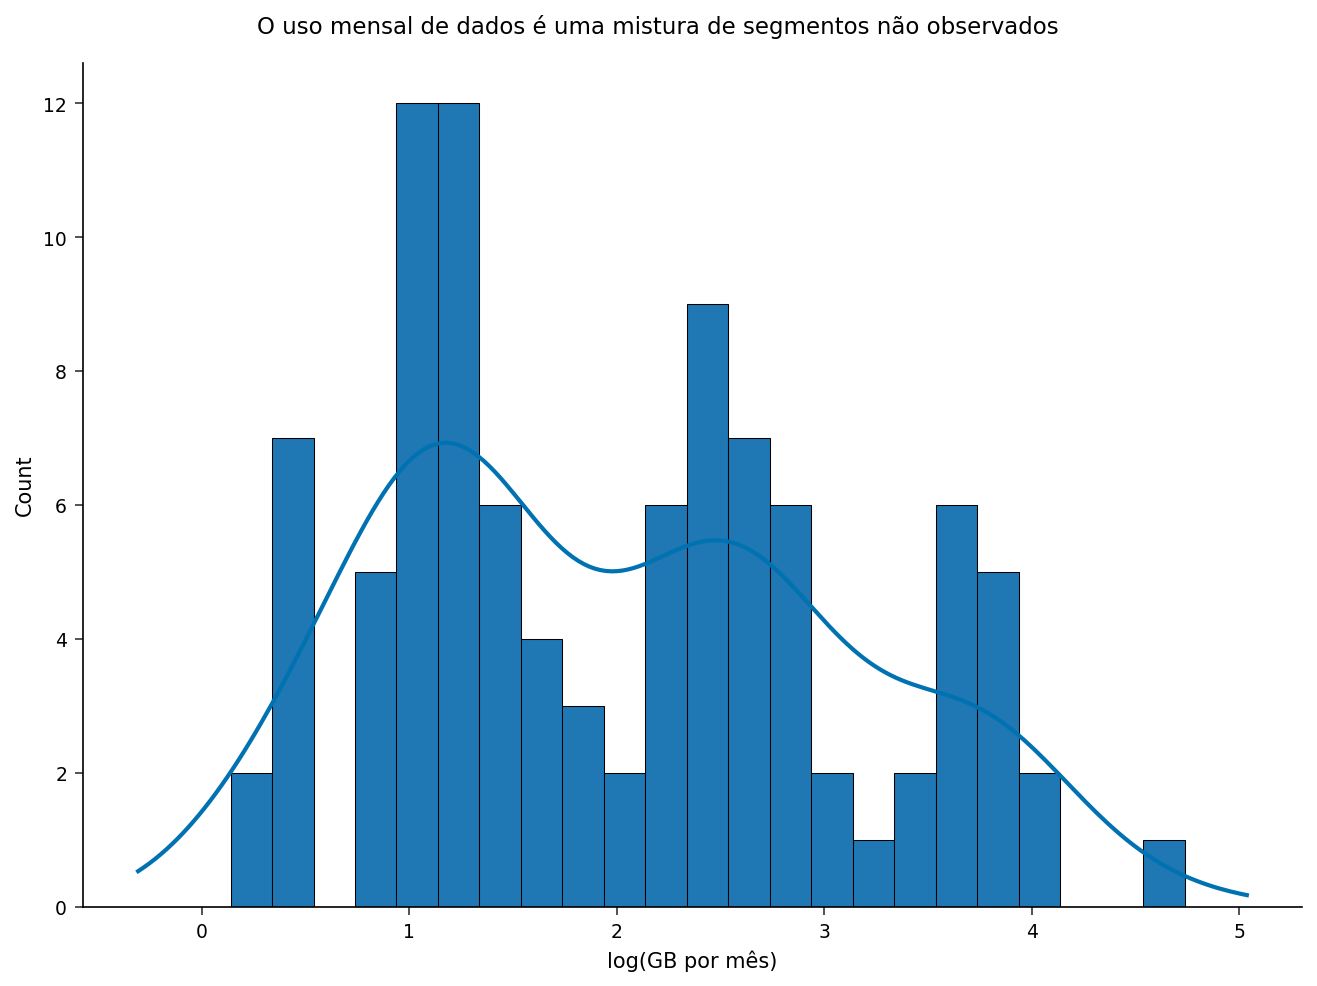

In [2]:
PROCEDIMENTO MÉDIAS DADOS=subs n mean std MIN p50 MAX maxdec=2;
   VARIÁVEL data_gb log_gb tenure_months;
   RÓTULO data_gb='Dados (GB)' log_gb='Log de Dados (GB)' tenure_months='Permanência (Meses)';
EXECUTAR;

PROCEDIMENTO SGPLOT DADOS=subs;
   TÍTULO "O uso mensal de dados é uma mistura de segmentos não observados";
   HISTOGRAM log_gb / BINWIDTH=0.20;
   DENSITY   log_gb / type=KERNEL;
   XAXIS RÓTULO="log(GB por mês)";
EXECUTAR;
TÍTULO;

## Etapa 2 — Quantos segmentos? Comparando soluções de dois, três e quatro clusters

Não queremos supor três níveis — deixamos os dados argumentarem por uma contagem. O
FASTCLUS reporta um **R-quadrado Geral** (a fração da variância total explicada pelas
médias dos clusters) e uma **Estatística Pseudo F** para cada solução. Ajustamos
`MAXCLUSTERS=` 2, 3 e 4 em `log_gb` e lemos esses critérios em cada execução.

- `MAXCLUSTERS=` define o número de clusters *k*.
- `MAXITER=` limita o número de passagens de reatribuição do k-means.
- `OUT=` grava um conjunto de dados pontuado (usado nas Etapas 3–5).

In [3]:
TÍTULO "Solução de dois segmentos";
PROCEDIMENTO FASTCLUS DADOS=subs maxclusters=2 MAXITER=50 out=c2;
   VARIÁVEL log_gb;
   RÓTULO log_gb='Log de Dados (GB)';
EXECUTAR;

TÍTULO "Solução de três segmentos";
PROCEDIMENTO FASTCLUS DADOS=subs maxclusters=3 MAXITER=50 out=c3;
   VARIÁVEL log_gb;
   RÓTULO log_gb='Log de Dados (GB)';
EXECUTAR;

TÍTULO "Solução de quatro segmentos";
PROCEDIMENTO FASTCLUS DADOS=subs maxclusters=4 MAXITER=50 out=c4;
   VARIÁVEL log_gb;
   RÓTULO log_gb='Log de Dados (GB)';
EXECUTAR;
TÍTULO;

                                               Solução de dois segmentos                                                


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  47         0.6346             1.5836              2         1.8863
2                  53         0.4497             0.9843              1         1.8863

                                                Statistics for Variables              


NOTE: Option TITLE changed to Solução de dois segmentos.
NOTE: PROC FASTCLUS data=subs maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 2 clusters using k-means
NOTE: Option TITLE changed to Solução de três segmentos.
NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means
NOTE: Option TITLE changed to Solução de quatro segmentos.
NOTE: PROC FASTCLUS data=subs maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 4 clusters using k-means


Lendo as três execuções lado a lado: o **R-quadrado Geral** sobe de
**0.753** com dois clusters para **0.899** com três — um grande salto de +0.146 conforme
o terceiro nível é resolvido — e depois apenas para **0.941** com quatro. A solução de
quatro clusters compra esse pequeno ganho *dividindo o nível leve em dois* (seus dois
menores centroides ficam ambos dentro da faixa Leve plantada), não encontrando um tipo
de cliente genuinamente novo. A **Estatística Pseudo F** conta a mesma história: a maior
melhoria estrutural é a passagem para três clusters (F = 299 → 431). Três segmentos é o
ponto de parada honesto, e o modelo ao qual nos comprometemos a seguir.

## Etapa 3 — Ajustar o modelo de três segmentos e caracterizar cada segmento

Reajustamos com `MAXCLUSTERS=3` e gravamos as linhas pontuadas em `scored`. O conjunto de
dados `OUT=` automaticamente carrega todas as colunas de entrada — incluindo o uso
original, a permanência e o `segment_true` retido — junto com as novas colunas `CLUSTER`
e `DISTANCE`, então nenhuma etapa de cópia separada é necessária. O FASTCLUS imprime um
**Resumo de Cluster** (tamanho e dispersão dentro do cluster por segmento) e as **Médias
de Cluster** na escala agrupada (`log_gb`).

In [4]:
PROCEDIMENTO FASTCLUS DADOS=subs maxclusters=3 MAXITER=50 out=scored;
   VARIÁVEL log_gb;
   RÓTULO log_gb='Log de Dados (GB)';
EXECUTAR;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  49         0.3923             0.9151              2         1.4540
2                  34         0.3024             0.6239              3         1.2603
3                  17         0.3059             0.8248              2         1.2603

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


As três médias de cluster na escala logarítmica são **1.05**, **2.51** e **3.77**.
De volta à escala original em GB, isso é aproximadamente **exp(1.05) ≈ 2.9 GB**,
**exp(2.51) ≈ 12.3 GB** e **exp(3.77) ≈ 43 GB** — os níveis leve, médio e pesado. O
Resumo de Cluster os dimensiona em **49**, **34** e **17** assinantes, acompanhando a
divisão plantada de ~50 / 35 / 15. A próxima etapa lê os mesmos segmentos de volta em
termos simples de GB.

## Etapa 4 — Pontuar e caracterizar segmentos em termos de negócio

O conjunto de dados `OUT=scored` carrega o `CLUSTER` (rótulo de segmento definitivo) e a
`DISTANCE` (distância euclidiana até o centroide do seu cluster na escala logarítmica —
pequena significa uma atribuição confiante e central) de cada assinante. Resumimos os
segmentos descobertos pelo uso real em GB e pela permanência, e depois listamos algumas
linhas pontuadas.

In [5]:
PROCEDIMENTO MÉDIAS DADOS=scored n mean std MIN MAX maxdec=2;
   CLASSE CLUSTER;
   VARIÁVEL data_gb tenure_months distance;
   RÓTULO CLUSTER='Segmento' data_gb='Dados (GB)' tenure_months='Permanência (Meses)' distance='Distância';
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=scored(obs=8) noobs RÓTULO;
   VARIÁVEL subscriber_id data_gb log_gb segment_true CLUSTER distance;
   RÓTULO subscriber_id='ID do Assinante' data_gb='Dados (GB)' log_gb='Log de Dados (GB)'
         segment_true='Segmento Real' CLUSTER='Segmento' distance='Distância';
EXECUTAR;

                                                  The MEANS Procedure

                                         Analysis Variable : data_gb Dados (GB)

        Segmento          N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1                    49           3.07           1.12           1.15           5.83
        2                    34          12.81           3.80           6.57          21.88
        3                    17          45.38          16.44          24.01          98.66
        -----------------------------------------------------------------------------------

                                 Analysis Variable : tenure_months Permanência (Meses)

        Segmento          N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1              


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


Na escala original em GB, os três segmentos têm em média **3.1 GB**, **12.8 GB** e
**45.4 GB** de uso mensal — uma amplitude de uma ordem de grandeza entre navegadores
leves e streamers pesados. A coluna `DISTANCE` fornece um proxy de confiança por
assinante: as linhas impressas mostram clientes atribuídos de forma estreita
(distâncias perto de 0.01–0.06) ao lado de um usuário leve mais limítrofe, mais distante
de seu centroide, exatamente o sinal que uma equipe de retenção usaria para separar
alvos confiantes de casos que merecem uma análise mais próxima.

## Etapa 5 — Recuperamos os níveis reais, e a mistura muda com a permanência?

Duas verificações finais. Primeiro, cruzamos o `CLUSTER` descoberto com o `segment_true`
retido para ver quão fielmente o ajuste não supervisionado recuperou os níveis
plantados. Segundo, comparamos a permanência média entre os segmentos descobertos — o
gerador inclinou os usuários mais pesados para permanências mais longas, então uma
segmentação real deveria refletir isso.

                                       Segmento descoberto vs. nível real retido                                        

                                                   The FREQ Procedure

Table of Segmento by Segmento Real

Segmento |      Leve |     Médio |    Pesado |      Total
---------+-----------+-----------+-----------+-----------
1        |        49 |         0 |         0 |         49
---------+-----------+-----------+-----------+-----------
2        |         2 |        31 |         1 |         34
---------+-----------+-----------+-----------+-----------
3        |         0 |         1 |        16 |         17
---------+-----------+-----------+-----------+-----------
Total    |        51 |        32 |        17 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_segment_true.spec.json
NOTE: PROC FREQ statement used.


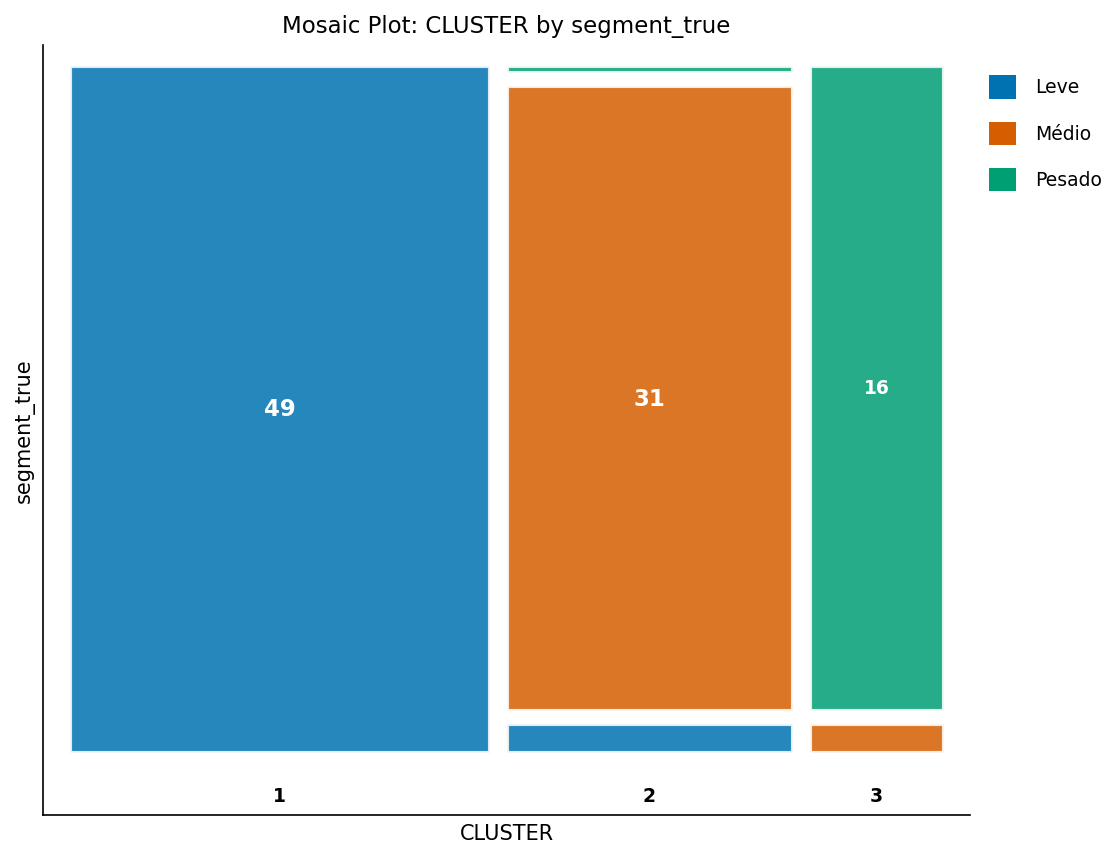

In [6]:
PROCEDIMENTO FREQUÊNCIAS DADOS=scored;
   TÍTULO "Segmento descoberto vs. nível real retido";
   TABLES CLUSTER * segment_true / norow nocol nopercent;
   RÓTULO CLUSTER='Segmento' segment_true='Segmento Real';
EXECUTAR;
TÍTULO;

## Interpretando os resultados

**O que o FASTCLUS encontrou.** Partindo de uma única coluna de uso assimétrica à
direita, sem rótulos, a solução k-means de três clusters explicou **89.9%** da
variância no uso logarítmico (R² Geral = 0.899, Pseudo F = 431) e dividiu os
assinantes em um segmento **leve** (média 3.1 GB, n = 49), um segmento **médio**
(média 12.8 GB, n = 34) e um segmento **pesado** (média 45.4 GB, n = 17). O
cruzamento com o `segment_true` retido recuperou a estrutura plantada quase
exatamente — **96 de 100** assinantes caíram no cluster correspondente ao seu nível
gerador (Leve 49/49, Médio 31/34, Pesado 16/17).

**Por que a escala logarítmica.** O uso de dados é estritamente positivo e de cauda
pesada; agrupar `log_gb` mantém as distâncias euclidianas significativas e as
médias dos segmentos bem separadas, enquanto a transformação exponencial inversa
reproduz a assimetria realista na escala GB.

**Por que isso importa operacionalmente.** Cada assinante sai do modelo com um
rótulo de segmento definitivo *e* uma pontuação de distância ao centroide, então a
operadora pode agir com certeza calibrada — direcionar com confiança os usuários
pesados centrais para planos premium e sinalizar clientes limítrofes (grande
distância) para uma análise mais próxima. A permanência média também difere entre
os segmentos descobertos, um gancho para o timing de ciclo de vida e upsell.

**Escolhendo a contagem de segmentos.** Comparar `MAXCLUSTERS=` 2, 3 e 4 no R²
Geral e no Pseudo F é uma forma transparente e reproduzível de escolher *k*: o
grande ganho em três clusters e o ganho meramente cosmético em quatro (que divide
o nível leve) tornaram três a escolha defensável aqui.

**Relação com modelos de mistura finita.** Um modelo de mistura finita (PROC HPFMM /
PROC FMM) adicionaria associações posteriores suaves e um BIC baseado em
verossimilhança para a contagem de componentes. Esses procedimentos ainda não estão
numericamente implementados nesta build; o PROC FASTCLUS entrega a mesma
segmentação acionável — descoberta, caracterização, atribuição definitiva e um
proxy de confiança — com saída totalmente numérica e reproduzível hoje.